<a href="https://colab.research.google.com/github/SawantSameer/csot-ml-astronomy/blob/main/Submissions/SameerSawant/week1/part2_myAttempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll join the official morphology labels to flat image files, build an `ImageFolder`-ready layout, create a `DataLoader` yielding `(32, 3, 64, 64)` batches, and plot a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

> **Heads-up:** The [Kaggle Galaxy Zoo 2 download](https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images) does **not** ship class subfolders. Images are named `{asset_id}.jpg` in a flat folder; labels live in CSV catalogues. We join them first, then use `ImageFolder`.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [1]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

The Kaggle bundle contains:
- `images_gz2.zip` — ~243k JPGs named `1.jpg`, `2.jpg`, … (no class folders)
- `gz2_filename_mapping.csv` — maps each `asset_id` to an SDSS `objid`

Morphology labels come separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)), which we download as `gz2_hart16.csv.gz`.

**Option A — Kaggle API (recommended).** Upload your `kaggle.json` token, then run the download/unzip commands in the solution notebook (or adapt the cell below).

Fill in the cell below to download/locate the data and set the paths.

In [2]:
import os
import json
import shutil
from pathlib import Path

# --- 1. KAGGLE AUTHENTICATION ---
# Replace with your EXACT username and key from your Kaggle account
kaggle_creds = {
  "username": "your_username_here",
  "key": "your_long_alphanumeric_key_here"
}

# Create the hidden Kaggle directory and write the credentials file
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# Lock down the file permissions for security
!chmod 600 /root/.kaggle/kaggle.json

# --- 2. DIRECTORY SETUP ---
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"
DATA_ROOT = Path("galaxy_data")
RAW_ROOT.mkdir(parents=True, exist_ok=True)

# --- 3. DOWNLOAD KAGGLE IMAGES ---
print("Authenticating and downloading images from Kaggle. This might take a minute...")
dataset_name = "jaimetrickz/galaxy-zoo-2-images"
!kaggle datasets download -d {dataset_name} -p {RAW_ROOT} --unzip

# --- 4. DOWNLOAD HART LABELS ---
print("Downloading Hart et al. morphology labels...")
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

# --- 5. FIX NESTED DIRECTORY ---
# Kaggle sometimes double-wraps the extracted folder. This flattens it.
nested_dir = IMAGES_DIR / "images_gz2"

if nested_dir.exists() and nested_dir.is_dir():
    print("Flattening the nested image directory...")
    for file in nested_dir.glob("*.jpg"):
        shutil.move(str(file), str(IMAGES_DIR))
    nested_dir.rmdir() # Clean up the empty duplicate folder

import shutil
from pathlib import Path

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("Hunting for the hidden images...")

# Recursively find ALL jpg files anywhere inside RAW_ROOT
all_jpgs = list(RAW_ROOT.rglob("*.jpg"))
print(f"Found {len(all_jpgs)} total images hiding in the raw folder!")

if len(all_jpgs) > 0:
    print("Moving them to the correct IMAGES_DIR... (This might take a minute)")

    # Ensure IMAGES_DIR exists
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

    # Move them all to the flat directory
    moved_count = 0
    for img_path in all_jpgs:
        # Only move if it's not already in the right spot
        if img_path.parent != IMAGES_DIR:
            shutil.move(str(img_path), str(IMAGES_DIR / img_path.name))
            moved_count += 1

    print(f"Successfully moved {moved_count} images!")

# Final Recount
print("\n--- Final Image Recount ---")
image_count = len(list(IMAGES_DIR.glob('*.jpg')))
print(f"Total images exactly in target folder: {image_count}")

if image_count > 240000:
    print("✅ Found them! Data pipeline setup successful! Ready for Step 2.")
else:
    print("⚠️ Warning: Something is still odd. Let me know what it prints!")



# --- 6. FINAL SANITY CHECK ---
print("\n--- Final Download Check ---")
print(f"Mapping CSV exists: {(RAW_ROOT / 'gz2_filename_mapping.csv').exists()}")
print(f"Hart labels CSV exists: {(RAW_ROOT / 'gz2_hart16.csv').exists()}")
print(f"Images folder exists: {IMAGES_DIR.exists()}")

if IMAGES_DIR.exists():
    image_count = len(list(IMAGES_DIR.glob('*.jpg')))
    print(f"Total images found: {image_count}")
    if image_count > 240000:
        print("✅ Data pipeline setup successful! Ready for Step 2.")
    else:
        print("⚠️ Warning: Image count seems low.")

Authenticating and downloading images from Kaggle. This might take a minute...
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:43<00:00, 75.8MB/s]

Hunting for the hidden images...
Found 243434 total images hiding in the raw folder!
Moving them to the correct IMAGES_DIR... (This might take a minute)
Successfully moved 243434 images!

--- Final Image Recount ---
Total images exactly in target folder: 243434
✅ Found them! Data pipeline setup successful! Ready for Step 2.

--- Final Download Check ---
Mapping CSV exists: True
Hart labels CSV exists: True
Images folder exists: True
Total images found: 243434
✅ Data pipeline setup successful! Ready for Step 2.


## Step 2 — Inspect the raw layout

List what's inside `RAW_ROOT` and peek at `IMAGES_DIR`. You should see a CSV mapping file and many JPGs named by integer ID — **not** morphology subfolders.

Also open `gz2_filename_mapping.csv` and confirm columns `objid`, `sample`, `asset_id`.

In [3]:
# TODO: print os.listdir(RAW_ROOT) and count a few files in IMAGES_DIR.
#       Hint: Path(IMAGES_DIR).glob("*.jpg")
import pandas as pd
from pathlib import Path

# Assuming these are still set from the previous cell
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("--- 1. Contents of RAW_ROOT ---")
# List everything sitting in the raw folder
for item in RAW_ROOT.iterdir():
    print(f" - {item.name}")

print("\n--- 2. Peek at IMAGES_DIR ---")
# Grab just the first 5 jpg files to verify the naming convention
sample_images = list(IMAGES_DIR.glob('*.jpg'))[:5]
for img in sample_images:
    print(f" - {img.name}")

print("\n--- 3. Checking gz2_filename_mapping.csv ---")
mapping_csv_path = RAW_ROOT / "gz2_filename_mapping.csv"

if mapping_csv_path.exists():
    # Load the CSV into a pandas DataFrame
    df_mapping = pd.read_csv(mapping_csv_path)

    print("Columns found:")
    print(df_mapping.columns.tolist())

    print("\nFirst 3 rows:")
    # Display the first few rows to see the actual data
    display(df_mapping.head(3))

    # Programmatic check for the specific columns
    expected_cols = {'objid', 'sample', 'asset_id'}
    actual_cols = set(df_mapping.columns)

    if expected_cols.issubset(actual_cols):
        print("\n✅ Success: Expected columns (objid, sample, asset_id) are all present!")
    else:
        print("\n⚠️ Warning: Missing expected columns.")
else:
    print(f"⚠️ Error: Could not find {mapping_csv_path}")

--- 1. Contents of RAW_ROOT ---
 - images_gz2
 - gz2_hart16.csv
 - gz2_filename_mapping.csv

--- 2. Peek at IMAGES_DIR ---
 - 24167.jpg
 - 4578.jpg
 - 241975.jpg
 - 213062.jpg
 - 41099.jpg

--- 3. Checking gz2_filename_mapping.csv ---
Columns found:
['objid', 'sample', 'asset_id']

First 3 rows:


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3



✅ Success: Expected columns (objid, sample, asset_id) are all present!


In [10]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

print("\nMapping CSV preview:")
print(pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3))

print("\nLabels CSV preview (note dr7objid — we rename to objid before merging):")
print(pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3)[["dr7objid", "gz2_class"]])

RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in /content/galaxy_raw/images_gz2: 243,434

Mapping CSV preview:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3

Labels CSV preview (note dr7objid — we rename to objid before merging):
             dr7objid gz2_class
0  587732591714893851      Sc+t
1  588009368545984617      Sb+t
2  587732484359913515        Ei


## Step 3 — Join labels and build an ImageFolder layout

`ImageFolder` expects `root/<class_name>/<image>.jpg`. Our Kaggle download doesn't provide that, so we:

1. Merge `gz2_filename_mapping.csv` with `gz2_hart16.csv` on `objid`.
2. Collapse the detailed `gz2_class` string (e.g. `Sc2t`, `Ei`) into a few high-level buckets.
3. Symlink a **balanced subset** into `DATA_ROOT/<class>/` so Colab stays fast.

Implement `high_level_label(gz2_class)` and `build_imagefolder_layout(...)` — see [`08-data-pipelines.md`](../08-data-pipelines.md).

In [11]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, …) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None  # artifact / ambiguous
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    """Join Kaggle mapping (objid ↔ asset_id) with Hart et al. morphology labels."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    return df


def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}/<class>/*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nExample rows:")
print(df[["asset_id", "objid", "gz2_class", "label"]].head())

Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64

Example rows:
   asset_id               objid gz2_class       label
0         3  587722981741363294        Sb      spiral
1         4  587722981741363323      Sc?l      spiral
2         5  587722981741559888        Er  elliptical
3         6  587722981741625481      Sc1t      spiral
4         7  587722981741625484        Sb      spiral


In [12]:
PER_CLASS = 200  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")

Linked images per class and split:
       elliptical  spiral  spiral_barred
train         140     140            140
val            30      30             30
test           30      30             30
train:  420 images  classes=['elliptical', 'spiral', 'spiral_barred']
val  :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']
test :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']


## Step 4 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [13]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Step 5 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically** — and only exist because we created the subfolders in Step 3.

In [14]:
train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}  n={len(ds):4d}  classes={ds.classes}")

print("class_to_idx:", train_ds.class_to_idx)

train  n= 420  classes=['elliptical', 'spiral', 'spiral_barred']
val    n=  90  classes=['elliptical', 'spiral', 'spiral_barred']
test   n=  90  classes=['elliptical', 'spiral', 'spiral_barred']
class_to_idx: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [15]:
# # A code to fix the symlink!
# import shutil
# from pathlib import Path

# # 1. Delete the broken folder
# DATA_ROOT = Path("galaxy_data")
# if DATA_ROOT.exists():
#     shutil.rmtree(DATA_ROOT)

# # 2. Grab the ABSOLUTE paths using .resolve()
# RAW_ROOT = Path("galaxy_raw").resolve()
# IMAGES_DIR = RAW_ROOT / "images_gz2"

# # 3. Re-run your exact builder function with the absolute paths
# build_imagefolder_layout(
#     images_dir=IMAGES_DIR,
#     mapping_csv=RAW_ROOT / "gz2_filename_mapping.csv",
#     hart_csv=RAW_ROOT / "gz2_hart16.csv",
#     dest_dir=DATA_ROOT.resolve(),
#     per_class=200
# )

# print("\n✅ Symlinks rebuilt with absolute paths!")



shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


## Step 6 — Fetch a single sample

In [16]:
image, label = train_ds[0]
print("shape :", image.shape)
print("dtype :", image.dtype)
print("label :", label, "->", train_ds.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


## Step 7 — Build a DataLoader and peek at one batch

In [17]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("train batch images:", images.shape)   # (32, 3, 64, 64)
print("train batch labels:", labels.shape)     # (32,)

train batch images: torch.Size([32, 3, 64, 64])
train batch labels: torch.Size([32])


## Step 8 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas:**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

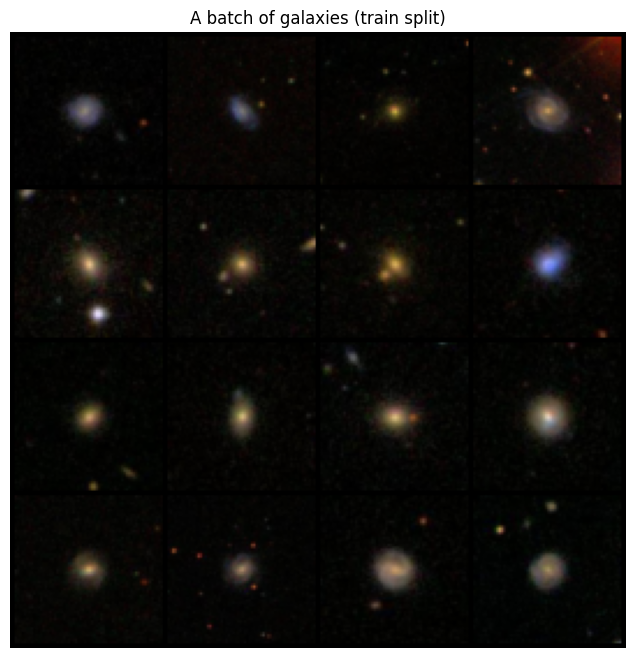

Labels: ['spiral', 'spiral_barred', 'spiral', 'spiral_barred', 'elliptical', 'spiral', 'elliptical', 'elliptical', 'spiral_barred', 'spiral', 'spiral', 'elliptical', 'spiral_barred', 'spiral_barred', 'spiral_barred', 'spiral_barred']


In [18]:
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies (train split)")
plt.show()

print("Labels:", [train_ds.classes[i] for i in labels[:16].tolist()])

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [ ]:
# TODO (optional): one or more stretch goals.

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?

*(
  
1. Most confusing part for me was to getting the dataset from the kaggle! I had to convert my API token into .json file so that I can retrieve the data!

2. For Spiral Galaxies, a CNN must detect low-level edge gradients to outline the sweeping, curved structures of the density-driven spiral arms.

3. Spiral barred and spirals! Because they look almost similar if the image isn't clear.

4. Because a machine learning model is completely blind without it; neural networks cannot process raw JPGs or unorganized data. The pipeline does the crucial heavy lifting of cleaning the data, matching images to their scientific labels, and transforming raw pixels into structured matrices (tensors) that a model can actually calculate and learn from. )*